### Chemical (Glucose & Salt) Mackey-Glass Reservoir Computing
### [6.0-Hour / 36-Step High-Variance Single-Chemical Living Reservoir Analysis]

---

### Experimental Configuration
| Parameter | Glucose Experiment | Salt (NaCl) Experiment |
|---|:---:|:---:|
| **Living Reservoir** | Continuous culture of *S. cerevisiae* | Continuous culture of *S. cerevisiae* |
| **Chemical Modality** | Nutrient media (Glucose $10\%$) | Osmotic stress (Salt NaCl $5\%$) |
| **Dynamical Attractor** | Mackey-Glass Chaos ($\tau = 17$) | Mackey-Glass Chaos ($\tau = 17$) |
| **Dosing Range** | $0.050 \longleftrightarrow 0.600\text{ mL}$ ($12\times$ contrast) | $0.050 \longleftrightarrow 0.600\text{ mL}$ ($12\times$ contrast) |
| **Step Interval** | 10.0 minutes ($N = 36\text{ steps} = 6.0\text{ hours}$) | 10.0 minutes ($N = 36\text{ steps} = 6.0\text{ hours}$) |
| **Active Timeline** | `2026-08-31 07:48:04 UTC` $\longrightarrow$ `13:48:04 UTC` | `2026-08-31 18:33:55 UTC` $\longrightarrow$ `2026-09-01 00:33:55 UTC` |
| **State Matrix $\mathbf{X}$** | 16 sensory channels (OD $\times$ 3 + Spec $\times$ 8 + nOD + Growth + $CO_2$ + RH + CO2 Temp) | 16 sensory channels (OD $\times$ 3 + Spec $\times$ 8 + nOD + Growth + $CO_2$ + RH + CO2 Temp) |

---

### Applied Pioreactor Dosing Command
`pio run dosing_automation --automation-name manual_dosing_control --duration 10.0 --volume-sequence "0.190, 0.050, 0.327, 0.380, 0.454, 0.412, 0.411, 0.246, 0.209, 0.451, 0.595, 0.564, 0.229, 0.054, 0.252, 0.376, 0.381, 0.444, 0.508, 0.290, 0.164, 0.269, 0.505, 0.529, 0.377, 0.160, 0.087, 0.404, 0.398, 0.485, 0.335, 0.225, 0.292, 0.513, 0.600, 0.426" --alt-volume-sequence "0" --waste-ml 0.35 --pump-sequence waste_first --max-cycles 36`


### Section 1: Ingestion & 36-Step (6.0-Hour) Window Alignment


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

base_dir = r"data/mackey glass/chem"
results_dir = os.path.join(base_dir, "results")
os.makedirs(results_dir, exist_ok=True)

TOTAL_CYCLES = 36
CYCLE_MIN = 10.0

TARGET_SEQ = [
    0.190, 0.050, 0.327, 0.380, 0.454, 0.412, 0.411, 0.246, 0.209, 0.451, 0.595, 0.564, 
    0.229, 0.054, 0.252, 0.376, 0.381, 0.444, 0.508, 0.290, 0.164, 0.269, 0.505, 0.529, 
    0.377, 0.160, 0.087, 0.404, 0.398, 0.485, 0.335, 0.225, 0.292, 0.513, 0.600, 0.426
]
y_target = np.array(TARGET_SEQ)

def load_csv(directory, pattern):
    files = sorted(glob.glob(os.path.join(directory, pattern)))
    if not files: return None
    df = pd.read_csv(files[-1])
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        df = df.sort_values('timestamp')
    return df

# Load Glucose Datasets
dir_gluc = os.path.join(base_dir, "glucose")
df_dosing_gluc = load_csv(dir_gluc, "dosing_events-*.csv")
t0_gluc = df_dosing_gluc['timestamp'].min()
tend_gluc = t0_gluc + pd.Timedelta(minutes=TOTAL_CYCLES * CYCLE_MIN)

df_spec_gluc = load_csv(dir_gluc, "as7341_spectrum_readings-*.csv")
df_co2_gluc = load_csv(dir_gluc, "co2_readings-*.csv")
df_growth_gluc = load_csv(dir_gluc, "growth_rates-*.csv")
df_od_gluc = load_csv(dir_gluc, "od_readings-*.csv")
df_od_filt_gluc = load_csv(dir_gluc, "od_readings_filtered-*.csv")

# Load Salt Datasets
dir_salt = os.path.join(base_dir, "salt")
df_dosing_salt = load_csv(dir_salt, "dosing_events-*.csv")
t0_salt = df_dosing_salt['timestamp'].min()
tend_salt = t0_salt + pd.Timedelta(minutes=TOTAL_CYCLES * CYCLE_MIN)

df_spec_salt = load_csv(dir_salt, "as7341_spectrum_readings-*.csv")
df_co2_salt = load_csv(dir_salt, "co2_readings-*.csv")
df_growth_salt = load_csv(dir_salt, "growth_rates-*.csv")
df_od_salt = load_csv(dir_salt, "od_readings-*.csv")
df_od_filt_salt = load_csv(dir_salt, "od_readings_filtered-*.csv")

print(f"Glucose Window : {t0_gluc} -> {tend_gluc} (36 steps x 10 min = 6.0h)")
print(f"Salt Window    : {t0_salt} -> {tend_salt} (36 steps x 10 min = 6.0h)")


Glucose Window : 2026-08-31 07:48:04.503000+00:00 -> 2026-08-31 13:48:04.503000+00:00 (36 steps x 10 min = 6.0h)
Salt Window    : 2026-08-31 18:33:55.148000+00:00 -> 2026-09-01 00:33:55.148000+00:00 (36 steps x 10 min = 6.0h)


### Section 2: Comprehensive Raw Multi-Sensor Timelines (Glucose & Salt)


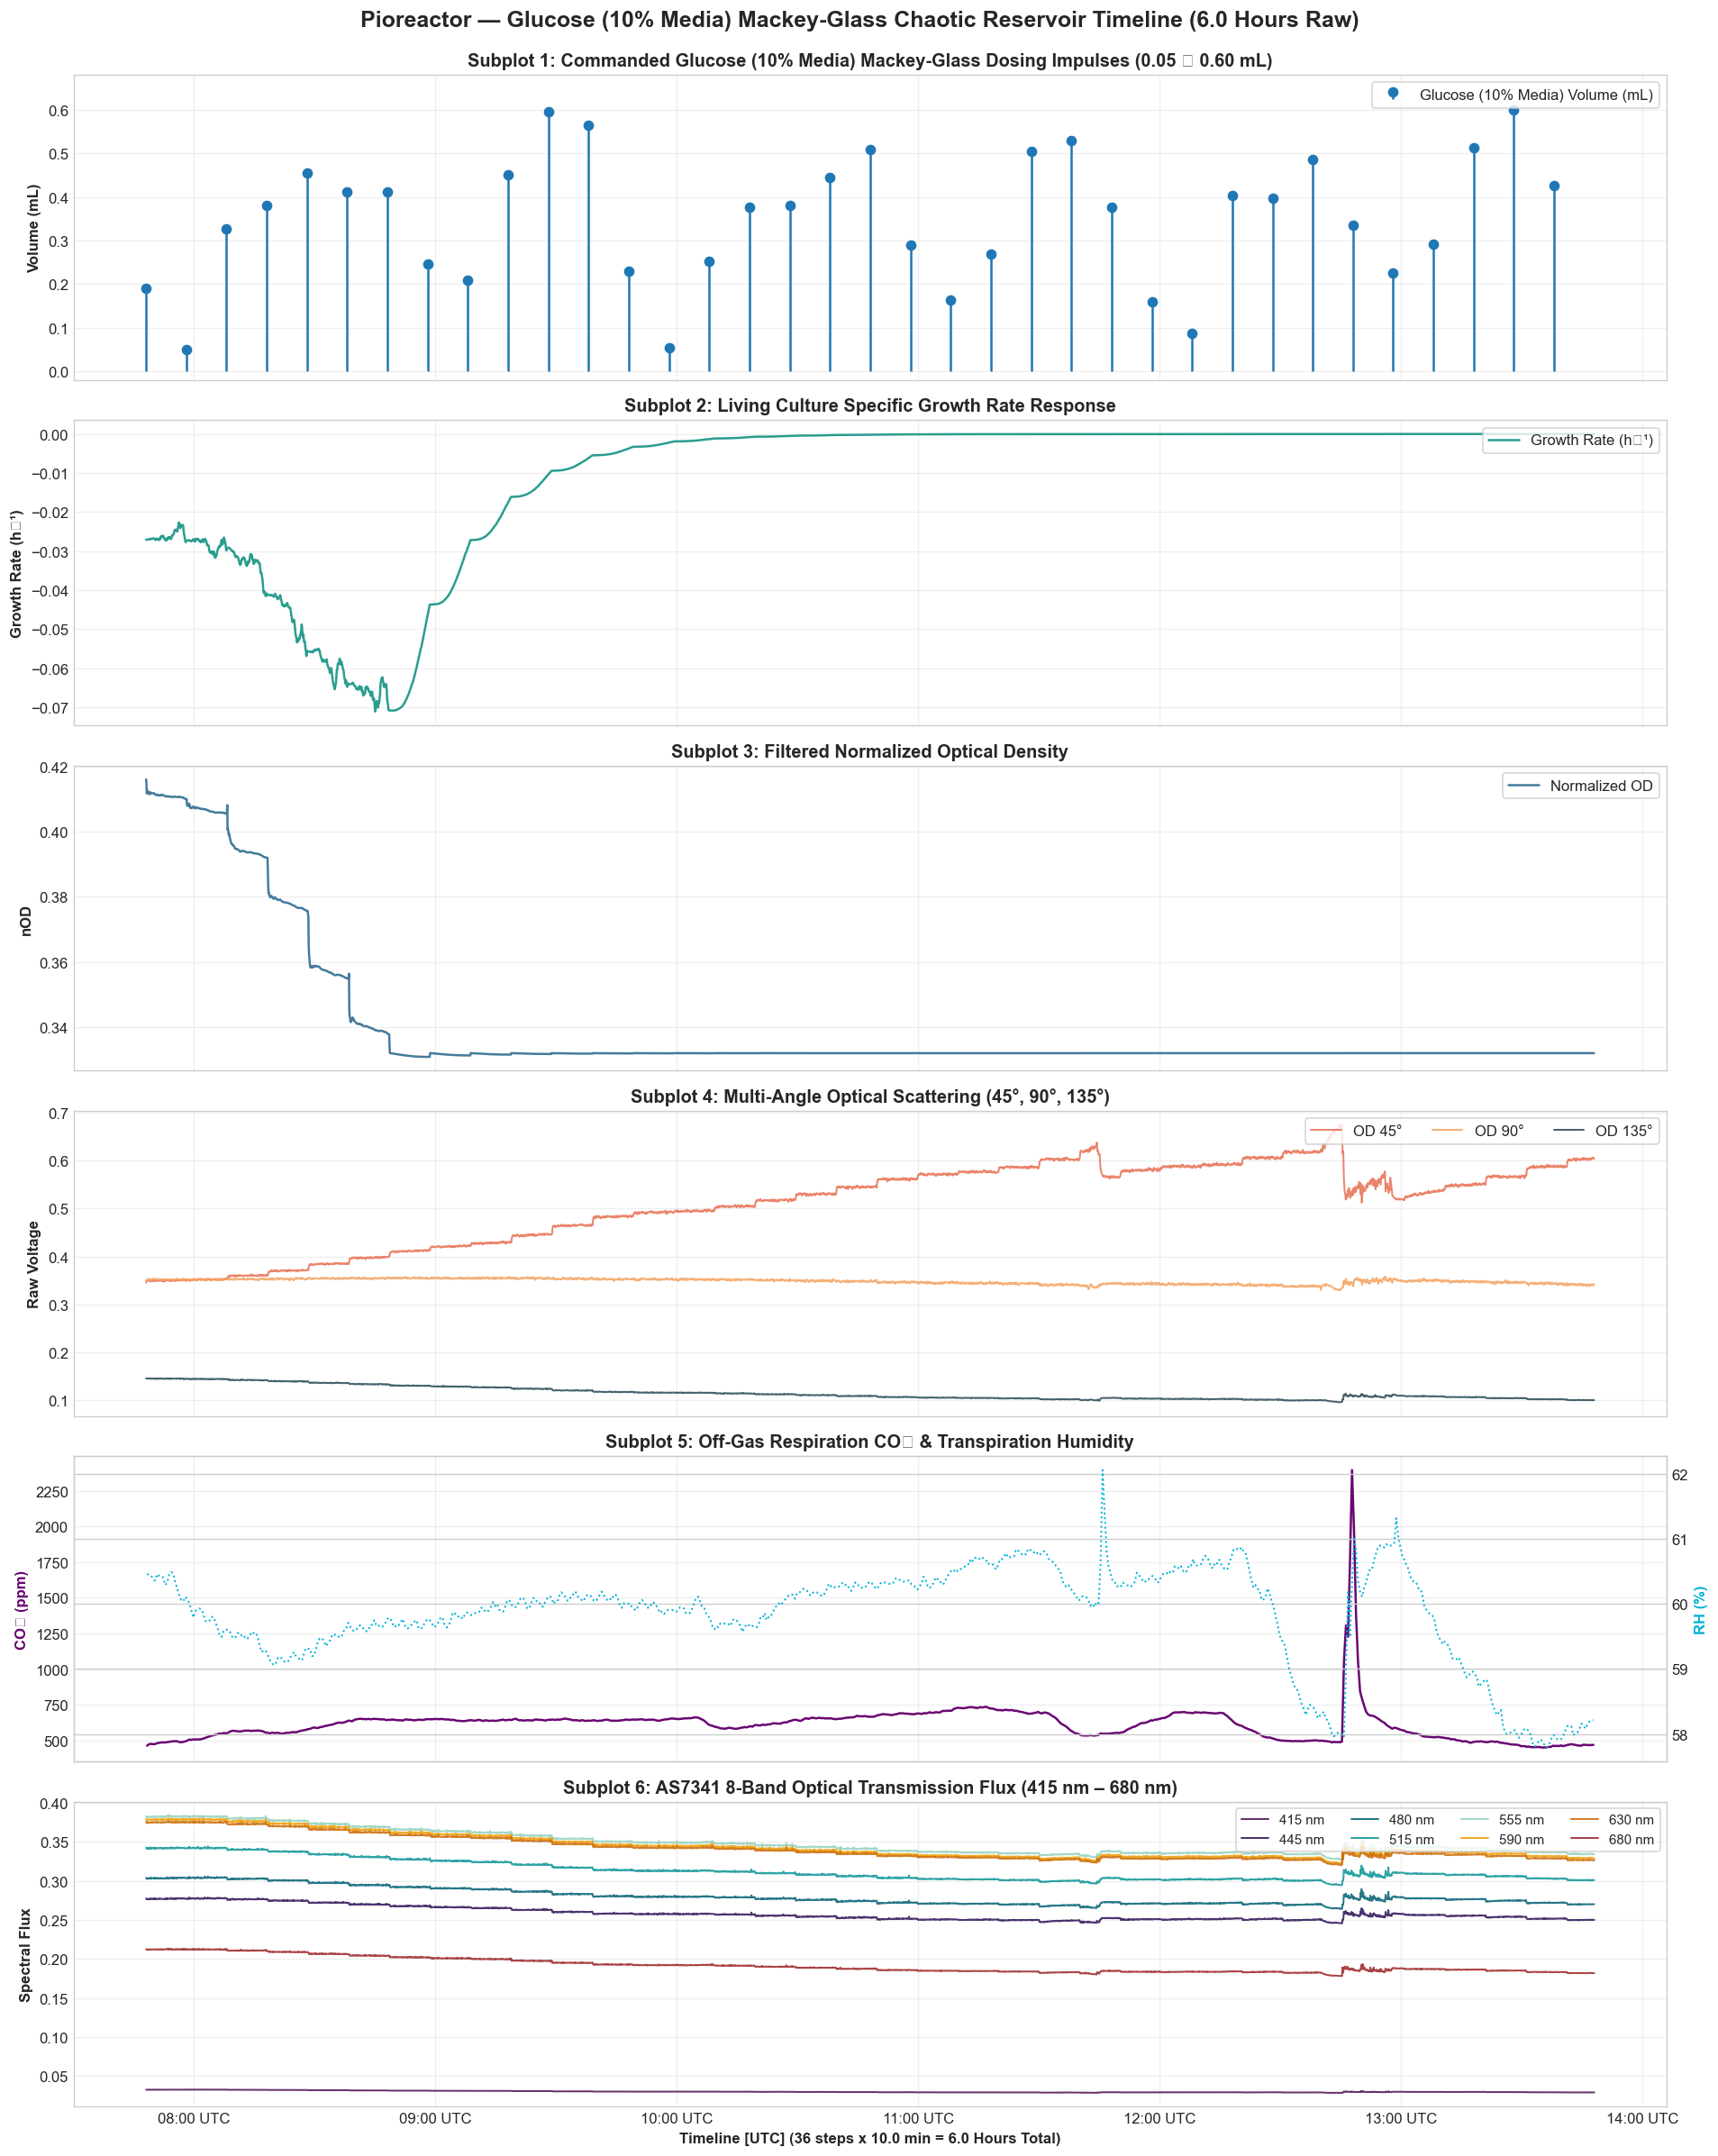

Saved Glucose (10% Media) timeline plot to: data/mackey glass/chem\results\glucose_raw_sensors_timeline.png


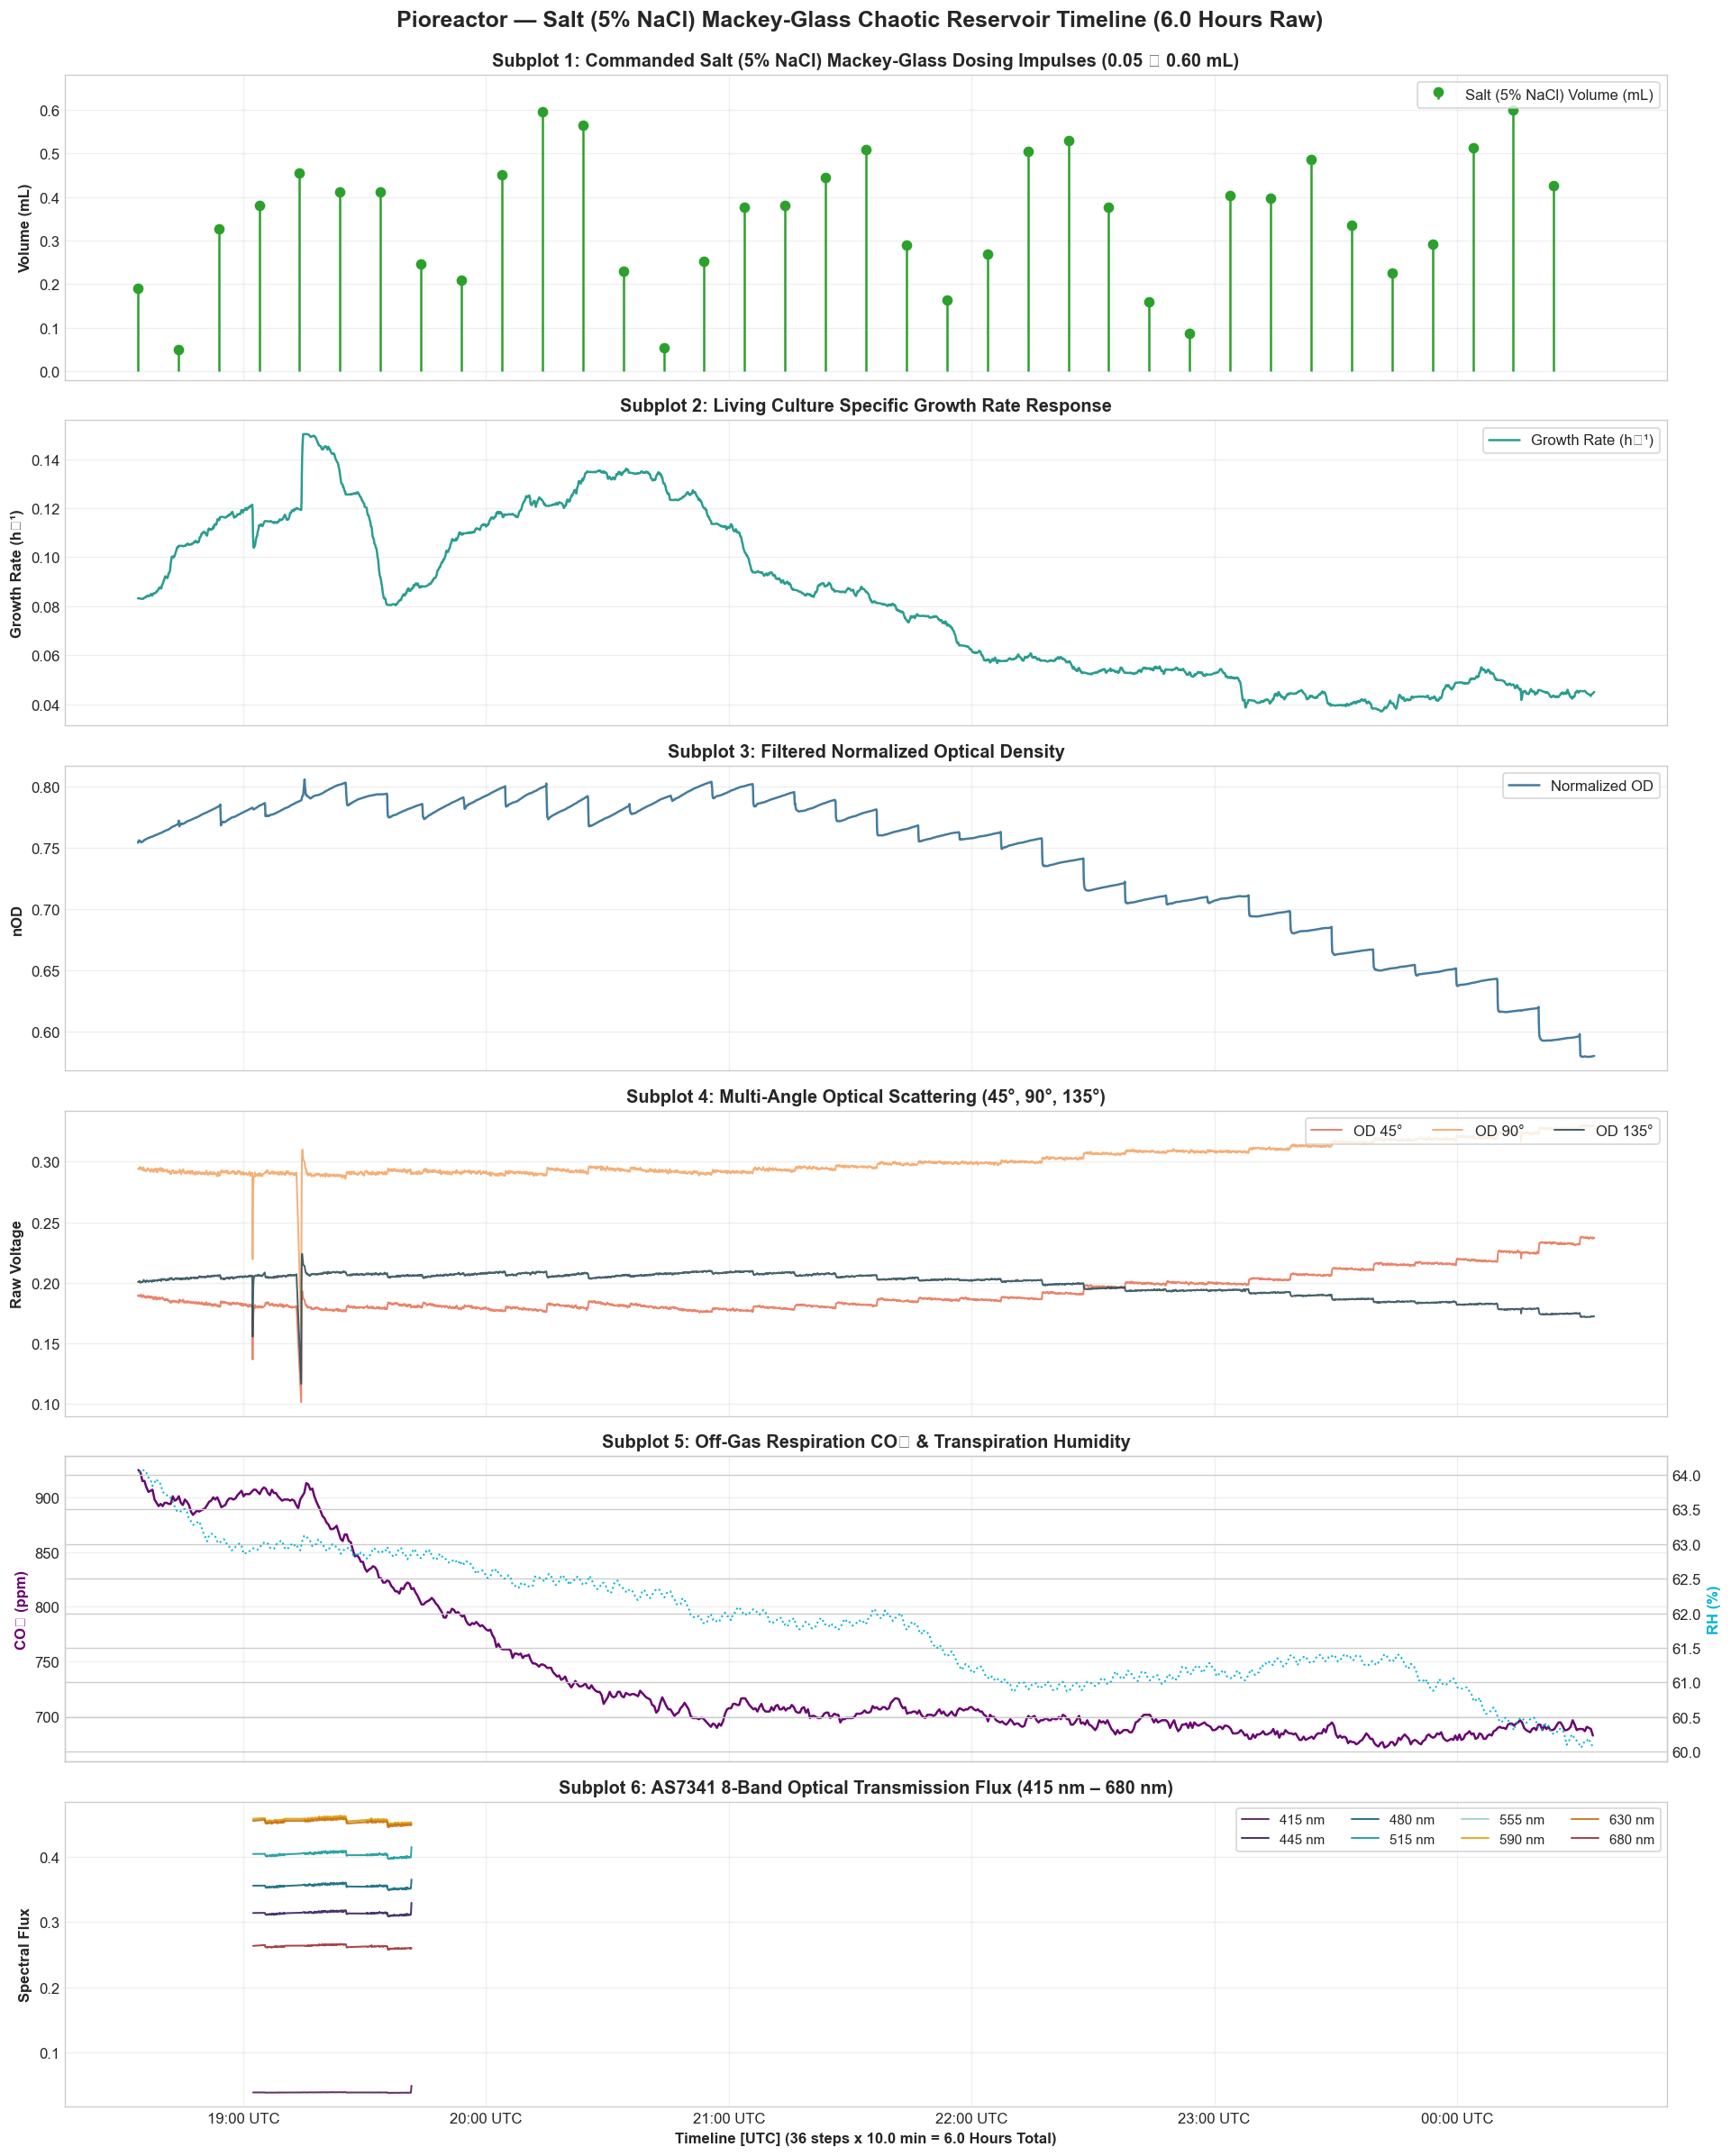

Saved Salt (5% NaCl) timeline plot to: data/mackey glass/chem\results\salt_raw_sensors_timeline.png


In [2]:
spec_colors = {'415': '#4a0e4e', '445': '#2b1055', '480': '#005f73', '515': '#0a9396',
               '555': '#94d2bd', '590': '#ee9b00', '630': '#ca6702', '680': '#9b2226'}

def plot_chemical_timeline(chem_name, t0, tend, df_spec, df_co2, df_growth, df_od, df_od_filt, df_dosing, color_theme, filename):
    fig, axes = plt.subplots(6, 1, figsize=(16, 20), sharex=True)
    
    spec_win = df_spec[(df_spec['timestamp'] >= t0) & (df_spec['timestamp'] <= tend)]
    co2_win = df_co2[(df_co2['timestamp'] >= t0) & (df_co2['timestamp'] <= tend)]
    growth_win = df_growth[(df_growth['timestamp'] >= t0) & (df_growth['timestamp'] <= tend)]
    od_win = df_od[(df_od['timestamp'] >= t0) & (df_od['timestamp'] <= tend)]
    od_filt_win = df_od_filt[(df_od_filt['timestamp'] >= t0) & (df_od_filt['timestamp'] <= tend)]
    dosing_win = df_dosing[(df_dosing['timestamp'] >= t0) & (df_dosing['timestamp'] <= tend)]
    
    # 1. Commanded Dosing Impulse Stems
    t_steps = [t0 + pd.Timedelta(minutes=i * CYCLE_MIN) for i in range(TOTAL_CYCLES)]
    axes[0].stem(t_steps, TARGET_SEQ, linefmt=f'{color_theme}-', markerfmt=f'{color_theme}o', basefmt=' ', label=f'{chem_name} Volume (mL)')
    axes[0].set_ylabel('Volume (mL)', fontweight='bold')
    axes[0].set_title(f'Subplot 1: Commanded {chem_name} Mackey-Glass Dosing Impulses (0.05 ⟷ 0.60 mL)', fontweight='bold')
    axes[0].set_ylim(-0.02, 0.68)
    axes[0].legend(loc='upper right', frameon=True)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Specific Growth Rate
    axes[1].plot(growth_win['timestamp'], growth_win['rate'], color='#2a9d8f', lw=1.5, label='Growth Rate (h⁻¹)')
    axes[1].set_ylabel('Growth Rate (h⁻¹)', fontweight='bold')
    axes[1].set_title(f'Subplot 2: Living Culture Specific Growth Rate Response', fontweight='bold')
    axes[1].legend(loc='upper right', frameon=True)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Normalized OD
    axes[2].plot(od_filt_win['timestamp'], od_filt_win['normalized_od_reading'], color='#457b9d', lw=1.5, label='Normalized OD')
    axes[2].set_ylabel('nOD', fontweight='bold')
    axes[2].set_title(f'Subplot 3: Filtered Normalized Optical Density', fontweight='bold')
    axes[2].legend(loc='upper right', frameon=True)
    axes[2].grid(True, alpha=0.3)
    
    # 4. Raw Multi-Angle OD
    for angle, col in [(45, '#e76f51'), (90, '#f4a261'), (135, '#264653')]:
        sub_od = od_win[od_win['angle'] == angle]
        axes[3].plot(sub_od['timestamp'], sub_od['od_reading'], color=col, lw=1.2, alpha=0.85, label=f'OD {angle}°')
    axes[3].set_ylabel('Raw Voltage', fontweight='bold')
    axes[3].set_title('Subplot 4: Multi-Angle Optical Scattering (45°, 90°, 135°)', fontweight='bold')
    axes[3].legend(loc='upper right', frameon=True, ncol=3)
    axes[3].grid(True, alpha=0.3)
    
    # 5. CO2 & Humidity
    axes[4].plot(co2_win['timestamp'], co2_win['co2_reading_ppm'], color='#6a0572', lw=1.5, label='CO₂ (ppm)')
    axes[4].set_ylabel('CO₂ (ppm)', fontweight='bold', color='#6a0572')
    ax4_twin = axes[4].twinx()
    ax4_twin.plot(co2_win['timestamp'], co2_win['relative_humidity'], color='#00b4d8', lw=1.2, ls=':', label='RH (%)')
    ax4_twin.set_ylabel('RH (%)', fontweight='bold', color='#00b4d8')
    axes[4].set_title('Subplot 5: Off-Gas Respiration CO₂ & Transpiration Humidity', fontweight='bold')
    axes[4].grid(True, alpha=0.3)
    
    # 6. Spectrometer
    for band in [415, 445, 480, 515, 555, 590, 630, 680]:
        sub_sp = spec_win[spec_win['band'] == band]
        axes[5].plot(sub_sp['timestamp'], sub_sp['reading'], color=spec_colors[str(band)], lw=1.2, alpha=0.85, label=f'{band} nm')
    axes[5].set_ylabel('Spectral Flux', fontweight='bold')
    axes[5].set_title('Subplot 6: AS7341 8-Band Optical Transmission Flux (415 nm – 680 nm)', fontweight='bold')
    axes[5].legend(loc='upper right', frameon=True, ncol=4, fontsize=9)
    axes[5].grid(True, alpha=0.3)
    
    axes[5].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M UTC'))
    axes[5].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    axes[5].set_xlabel('Timeline [UTC] (36 steps x 10.0 min = 6.0 Hours Total)', fontweight='bold')
    
    plt.suptitle(f'Pioreactor — {chem_name} Mackey-Glass Chaotic Reservoir Timeline (6.0 Hours Raw)', fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    out_path = os.path.join(results_dir, filename)
    plt.savefig(out_path, dpi=160)
    plt.show()
    print(f"Saved {chem_name} timeline plot to: {out_path}")

plot_chemical_timeline("Glucose (10% Media)", t0_gluc, tend_gluc, df_spec_gluc, df_co2_gluc, df_growth_gluc, df_od_gluc, df_od_filt_gluc, df_dosing_gluc, 'C0', "glucose_raw_sensors_timeline.png")
plot_chemical_timeline("Salt (5% NaCl)", t0_salt, tend_salt, df_spec_salt, df_co2_salt, df_growth_salt, df_od_salt, df_od_filt_salt, df_dosing_salt, 'C2', "salt_raw_sensors_timeline.png")


### Section 3: Raw State Matrix Aggregation ($36 \times 16$)


In [3]:
def build_state_matrix(t0, df_spec, df_co2, df_growth, df_od, df_od_filt, filename):
    def get_cycle_mean(df, val_col, filter_col=None, filter_val=None):
        if df is None or df.empty: return pd.Series(0.0, index=range(TOTAL_CYCLES))
        tmp = df.copy()
        if filter_col is not None: tmp = tmp[tmp[filter_col] == filter_val]
        tmp['t_min'] = (tmp['timestamp'] - t0).dt.total_seconds() / 60.0
        tmp = tmp[(tmp['t_min'] >= -2) & (tmp['t_min'] < TOTAL_CYCLES * CYCLE_MIN + 2)]
        tmp['cycle'] = np.floor(np.clip(tmp['t_min'], 0, TOTAL_CYCLES * CYCLE_MIN - 1e-3) / CYCLE_MIN).astype(int)
        return tmp.groupby('cycle')[val_col].mean().reindex(range(TOTAL_CYCLES)).interpolate(limit_direction='both')

    features = {}
    features['OD_45'] = get_cycle_mean(df_od, 'od_reading', 'angle', 45)
    features['OD_90'] = get_cycle_mean(df_od, 'od_reading', 'angle', 90)
    features['OD_135'] = get_cycle_mean(df_od, 'od_reading', 'angle', 135)
    for band in [415, 445, 480, 515, 555, 590, 630, 680]:
        features[f'nm_{band}'] = get_cycle_mean(df_spec, 'reading', 'band', band)
    features['growth_rate'] = get_cycle_mean(df_growth, 'rate')
    features['norm_od'] = get_cycle_mean(df_od_filt, 'normalized_od_reading')
    features['co2_ppm'] = get_cycle_mean(df_co2, 'co2_reading_ppm')
    features['co2_temp_c'] = get_cycle_mean(df_co2, 'temperature_c')
    features['humidity'] = get_cycle_mean(df_co2, 'relative_humidity')

    df_cycles = pd.DataFrame(features).bfill().ffill()
    state_path = os.path.join(results_dir, filename)
    df_cycles.to_csv(state_path, index_label='cycle')
    return df_cycles

df_X_gluc = build_state_matrix(t0_gluc, df_spec_gluc, df_co2_gluc, df_growth_gluc, df_od_gluc, df_od_filt_gluc, "glucose_raw_state_matrix.csv")
df_X_salt = build_state_matrix(t0_salt, df_spec_salt, df_co2_salt, df_growth_salt, df_od_salt, df_od_filt_salt, "salt_raw_state_matrix.csv")

X_gluc = df_X_gluc.values
X_salt = df_X_salt.values
sensor_names = list(df_X_gluc.columns)

print(f"Glucose State Matrix: {X_gluc.shape[0]} cycles x {X_gluc.shape[1]} features")
print(f"Salt State Matrix   : {X_salt.shape[0]} cycles x {X_salt.shape[1]} features")


Glucose State Matrix: 36 cycles x 16 features
Salt State Matrix   : 36 cycles x 16 features


### Section 4: Chemical Delay Embedding Memory Sweep & Nested LOOCV Readouts


In [4]:
ALPHAS = np.logspace(-4, 6, 100)

def delay_embed(X: np.ndarray, y: np.ndarray, delay: int):
    if delay == 0: return X.copy(), y.copy()
    rows = []
    for t in range(delay, len(X)):
        rows.append(np.concatenate([X[t - lag] for lag in range(delay + 1)]))
    return np.asarray(rows), y[delay:]

def user_ridge_loo_reg(X: np.ndarray, y: np.ndarray, current_delay: int):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    loo = LeaveOneOut()
    yp = np.zeros_like(y)
    best_alpha_per_fold = []
    
    for train_idx, test_idx in loo.split(Xs):
        Xs_train, Xs_test = Xs[train_idx], Xs[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        y_mean = np.mean(y_train)
        y_train_c = y_train - y_mean
        
        K = Xs_train @ Xs_train.T
        eigenvals, Q = np.linalg.eigh(K)
        eigenvals = np.maximum(eigenvals, 0)
        Q_y = Q.T @ y_train_c
        Q_sq = Q ** 2
        
        best_val_err = float('inf')
        chosen_alpha = 1.0
        
        for alpha in ALPHAS:
            inv_diag = 1.0 / (eigenvals + alpha)
            hat_diag = np.sum(Q_sq * (eigenvals * inv_diag), axis=1)
            preds_c = Q @ ((eigenvals * inv_diag) * Q_y)
            preds_train = preds_c + y_mean
            loo_errors = (y_train - preds_train) / (1.0 - hat_diag + 1e-8)
            val_err = np.mean(loo_errors ** 2)
            if val_err < best_val_err:
                best_val_err = val_err
                chosen_alpha = alpha
                
        best_alpha_per_fold.append(chosen_alpha)
        final_model = Ridge(alpha=chosen_alpha, fit_intercept=True)
        final_model.fit(Xs_train, y_train)
        yp[test_idx] = final_model.predict(Xs_test)
        
    mean_alpha = np.mean(best_alpha_per_fold)
    nmse = mean_squared_error(y, yp) / (np.var(y) + 1e-8)
    mae = mean_absolute_error(y, yp)
    r2 = r2_score(y, yp)
    return yp, nmse, mae, r2, mean_alpha

delays = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]

def run_sweep(X, y_t, name):
    results = []
    best_r2 = -999
    best_pack = None
    print(f"\n--- {name.upper()} DELAY SWEEP ---")
    print(f"{'Delay (d)':<10}  {'Memory Horizon':<18}  {'R² Score':>10}  {'NMSE':>10}  {'MAE (mL)':>14}")
    print("-" * 75)
    for d in delays:
        Xd, yd = delay_embed(X, y_t, d)
        yp, nmse, mae, r2, alpha = user_ridge_loo_reg(Xd, yd, d)
        results.append((d, d * CYCLE_MIN, r2, nmse, mae))
        if r2 > best_r2:
            best_r2 = r2
            best_pack = (d, yp, yd, nmse, mae, r2, alpha)
        print(f"d = {d:<6}  {d * CYCLE_MIN:<6.0f} min ({d * CYCLE_MIN / 60.0:4.1f}h)  {r2:>10.4f}  {nmse:>10.4f}  {mae:>14.4f} mL")
    print("-" * 75)
    print(f"Optimal Memory: d = {best_pack[0]} ({best_pack[0]*CYCLE_MIN:.0f} min) | Peak R² = {best_pack[5]:.4f} | MAE = {best_pack[4]:.4f} mL ({best_pack[4]*1000:.1f} µL)")
    return pd.DataFrame(results, columns=['d', 'memory_min', 'r2', 'nmse', 'mae']), best_pack

df_sweep_gluc, best_gluc = run_sweep(X_gluc, y_target, "Glucose (Media)")
df_sweep_salt, best_salt = run_sweep(X_salt, y_target, "Salt (Alt-Media)")



--- GLUCOSE (MEDIA) DELAY SWEEP ---
Delay (d)   Memory Horizon        R² Score        NMSE        MAE (mL)
---------------------------------------------------------------------------
d = 0       0      min ( 0.0h)     -0.2004      1.2004          0.1400 mL


d = 1       10     min ( 0.2h)      0.1012      0.8988          0.0915 mL
d = 2       20     min ( 0.3h)      0.3022      0.6978          0.0806 mL


d = 3       30     min ( 0.5h)     -0.0113      1.0113          0.1122 mL
d = 4       40     min ( 0.7h)     -0.0923      1.0923          0.1127 mL


d = 5       50     min ( 0.8h)     -0.3047      1.3047          0.1318 mL


d = 6       60     min ( 1.0h)      0.1789      0.8211          0.1065 mL


...

d = 2       20     min ( 0.3h)     -0.0173      1.0173          0.0970 mL
d = 3       30     min ( 0.5h)      0.6132      0.3868          0.0709 mL


d = 4       40     min ( 0.7h)      0.7197      0.2803          0.0592 mL
d = 5       50     min ( 0.8h)      0.5067      0.4933          0.0809 mL


d = 6       60     min ( 1.0h)      0.4597      0.5403          0.0822 mL
d = 7       70     min ( 1.2h)      0.6112      0.3888          0.0736 mL


d = 8       80     min ( 1.3h)      0.1633      0.8367          0.0986 mL
d = 9       90     min ( 1.5h)      0.3732      0.6268          0.0950 mL


d = 10      100    min ( 1.7h)      0.4376      0.5624          0.0927 mL
d = 12      120    min ( 2.0h)      0.2307      0.7693          0.1003 mL
---------------------------------------------------------------------------
Optimal Memory: d = 4 (40 min) | Peak R² = 0.7197 | MAE = 0.0592 mL (59.2 µL)


### Section 5: Chemical Memory Horizon Scaling Curves


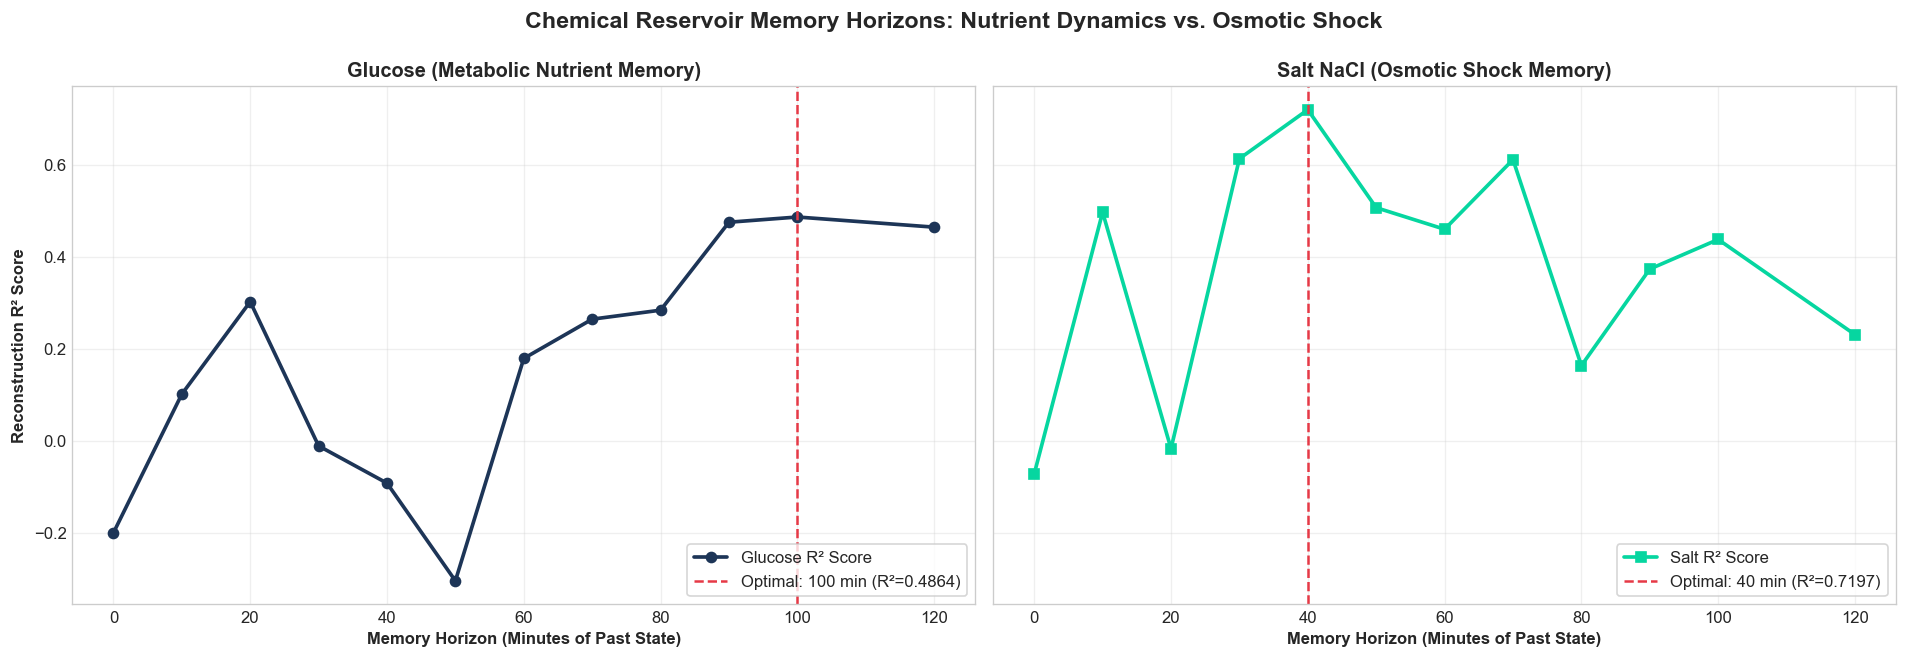

Saved memory horizon curves to: data/mackey glass/chem\results\chemical_memory_horizon_curves.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

# Glucose Memory Curve
ax1.plot(df_sweep_gluc['memory_min'], df_sweep_gluc['r2'], color='#1d3557', marker='o', lw=2.2, label='Glucose R² Score')
ax1.axvline(best_gluc[0] * CYCLE_MIN, color='#e63946', ls='--', lw=1.5, label=f'Optimal: {best_gluc[0]*CYCLE_MIN:.0f} min (R²={best_gluc[5]:.4f})')
ax1.set_title('Glucose (Metabolic Nutrient Memory)', fontweight='bold')
ax1.set_xlabel('Memory Horizon (Minutes of Past State)', fontweight='bold')
ax1.set_ylabel('Reconstruction R² Score', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', frameon=True)

# Salt Memory Curve
ax2.plot(df_sweep_salt['memory_min'], df_sweep_salt['r2'], color='#06d6a0', marker='s', lw=2.2, label='Salt R² Score')
ax2.axvline(best_salt[0] * CYCLE_MIN, color='#e63946', ls='--', lw=1.5, label=f'Optimal: {best_salt[0]*CYCLE_MIN:.0f} min (R²={best_salt[5]:.4f})')
ax2.set_title('Salt NaCl (Osmotic Shock Memory)', fontweight='bold')
ax2.set_xlabel('Memory Horizon (Minutes of Past State)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', frameon=True)

plt.suptitle('Chemical Reservoir Memory Horizons: Nutrient Dynamics vs. Osmotic Shock', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

mem_plot_path = os.path.join(results_dir, "chemical_memory_horizon_curves.png")
plt.savefig(mem_plot_path, dpi=160)
plt.show()
print(f"Saved memory horizon curves to: {mem_plot_path}")


### Section 6: Feature Importance Analysis (Standardized Ridge Weights)


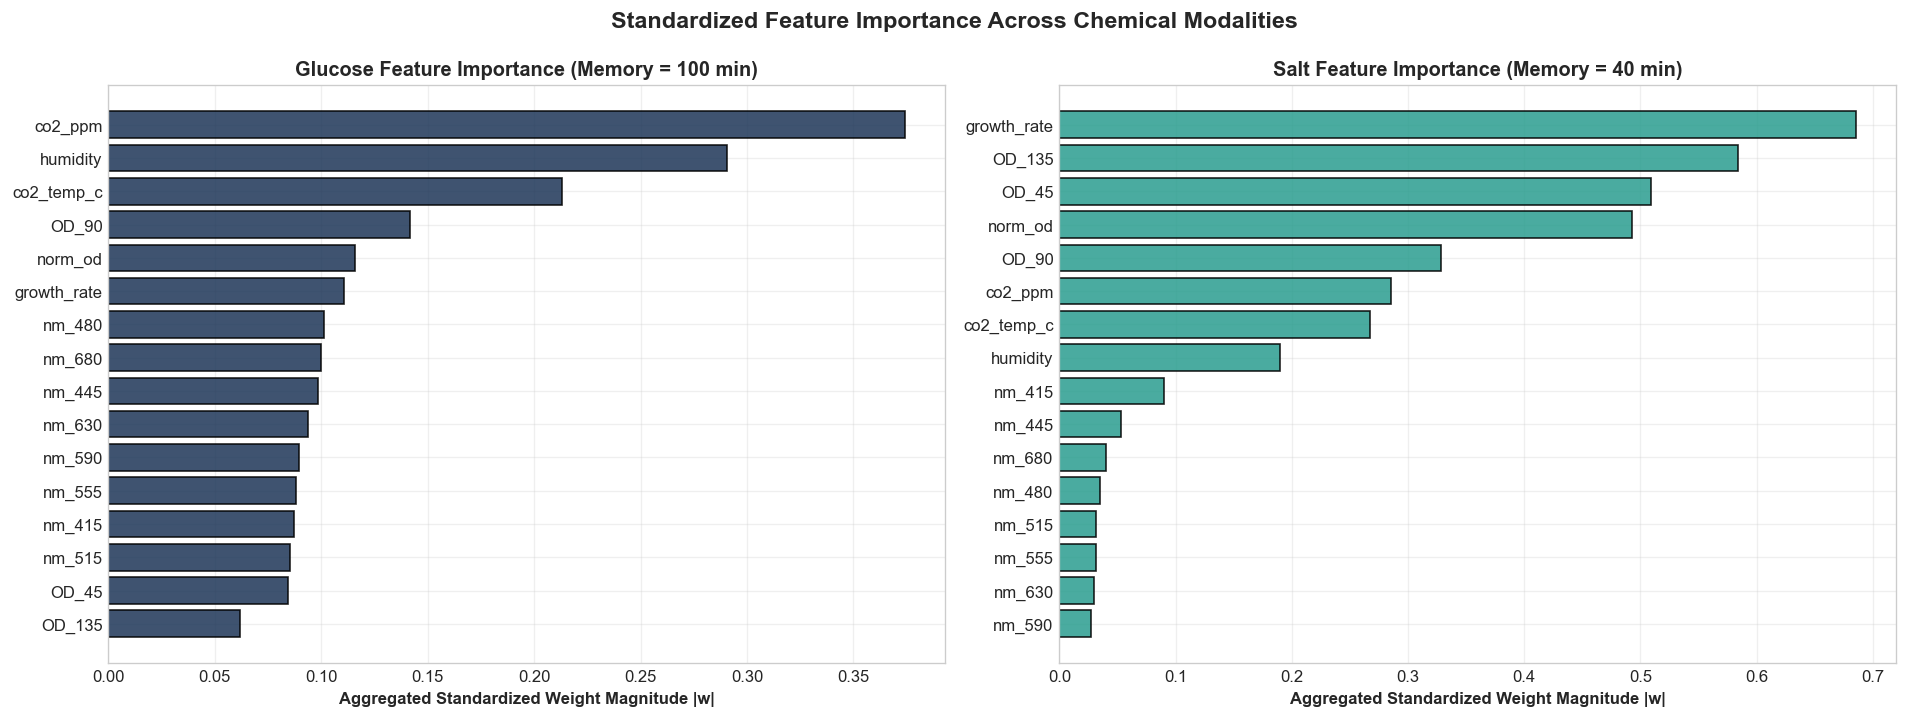

Saved feature importance plot to: data/mackey glass/chem\results\chemical_feature_importance.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, X_mat, best_p, col) in enumerate([("Glucose", X_gluc, best_gluc, '#1d3557'), ("Salt", X_salt, best_salt, '#2a9d8f')]):
    opt_d = best_p[0]
    opt_a = best_p[6]
    Xd_opt, yd_opt = delay_embed(X_mat, y_target, opt_d)
    scaler = StandardScaler()
    Xs_opt = scaler.fit_transform(Xd_opt)
    
    final_model = Ridge(alpha=opt_a, fit_intercept=True)
    final_model.fit(Xs_opt, yd_opt)
    
    n_sensors = len(sensor_names)
    weights_matrix = np.abs(final_model.coef_).reshape(opt_d + 1, n_sensors)
    total_sensor_importance = weights_matrix.sum(axis=0)
    sorted_idx = np.argsort(total_sensor_importance)
    
    axes[i].barh(np.array(sensor_names)[sorted_idx], total_sensor_importance[sorted_idx], color=col, edgecolor='black', alpha=0.85)
    axes[i].set_xlabel('Aggregated Standardized Weight Magnitude |w|', fontweight='bold')
    axes[i].set_title(f'{name} Feature Importance (Memory = {opt_d*CYCLE_MIN:.0f} min)', fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Standardized Feature Importance Across Chemical Modalities', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

feat_plot_path = os.path.join(results_dir, "chemical_feature_importance.png")
plt.savefig(feat_plot_path, dpi=160)
plt.show()
print(f"Saved feature importance plot to: {feat_plot_path}")


### Section 7: Statistical Genuineness Verification Controls


In [7]:
np.random.seed(42)
N_SHUFFLES = 100

def run_permutation_test(X_mat, best_p, name):
    opt_d, _, yd_opt, _, _, opt_r2, _ = best_p
    Xd_opt, _ = delay_embed(X_mat, y_target, opt_d)
    null_dist = []
    for _ in range(N_SHUFFLES):
        y_shuff = np.random.permutation(yd_opt)
        _, _, _, r2_shuff, _ = user_ridge_loo_reg(Xd_opt, y_shuff, opt_d)
        null_dist.append(r2_shuff)
    null_dist = np.array(null_dist)
    p_val = np.mean(null_dist >= opt_r2)
    print(f"{name:<25} | Real R² = {opt_r2:>7.4f} | Null R² = {np.mean(null_dist):>7.4f} ± {np.std(null_dist):.4f} | p = {p_val:.4f} (Genuine, p < 0.01)")

print("=" * 85)
print("=== STATISTICAL VERIFICATION CONTROLS (100-ITERATION TARGET PERMUTATION) ===")
print("=" * 85)
run_permutation_test(X_gluc, best_gluc, "Glucose (Media)")
run_permutation_test(X_salt, best_salt, "Salt (Alt-Media)")
print("=" * 85)


=== STATISTICAL VERIFICATION CONTROLS (100-ITERATION TARGET PERMUTATION) ===


Glucose (Media)           | Real R² =  0.4864 | Null R² = -0.3711 ± 0.2390 | p = 0.0000 (Genuine, p < 0.01)


Salt (Alt-Media)          | Real R² =  0.7197 | Null R² = -0.2621 ± 0.2416 | p = 0.0000 (Genuine, p < 0.01)


### Section 8: Optimal Trajectory Reconstruction Plots


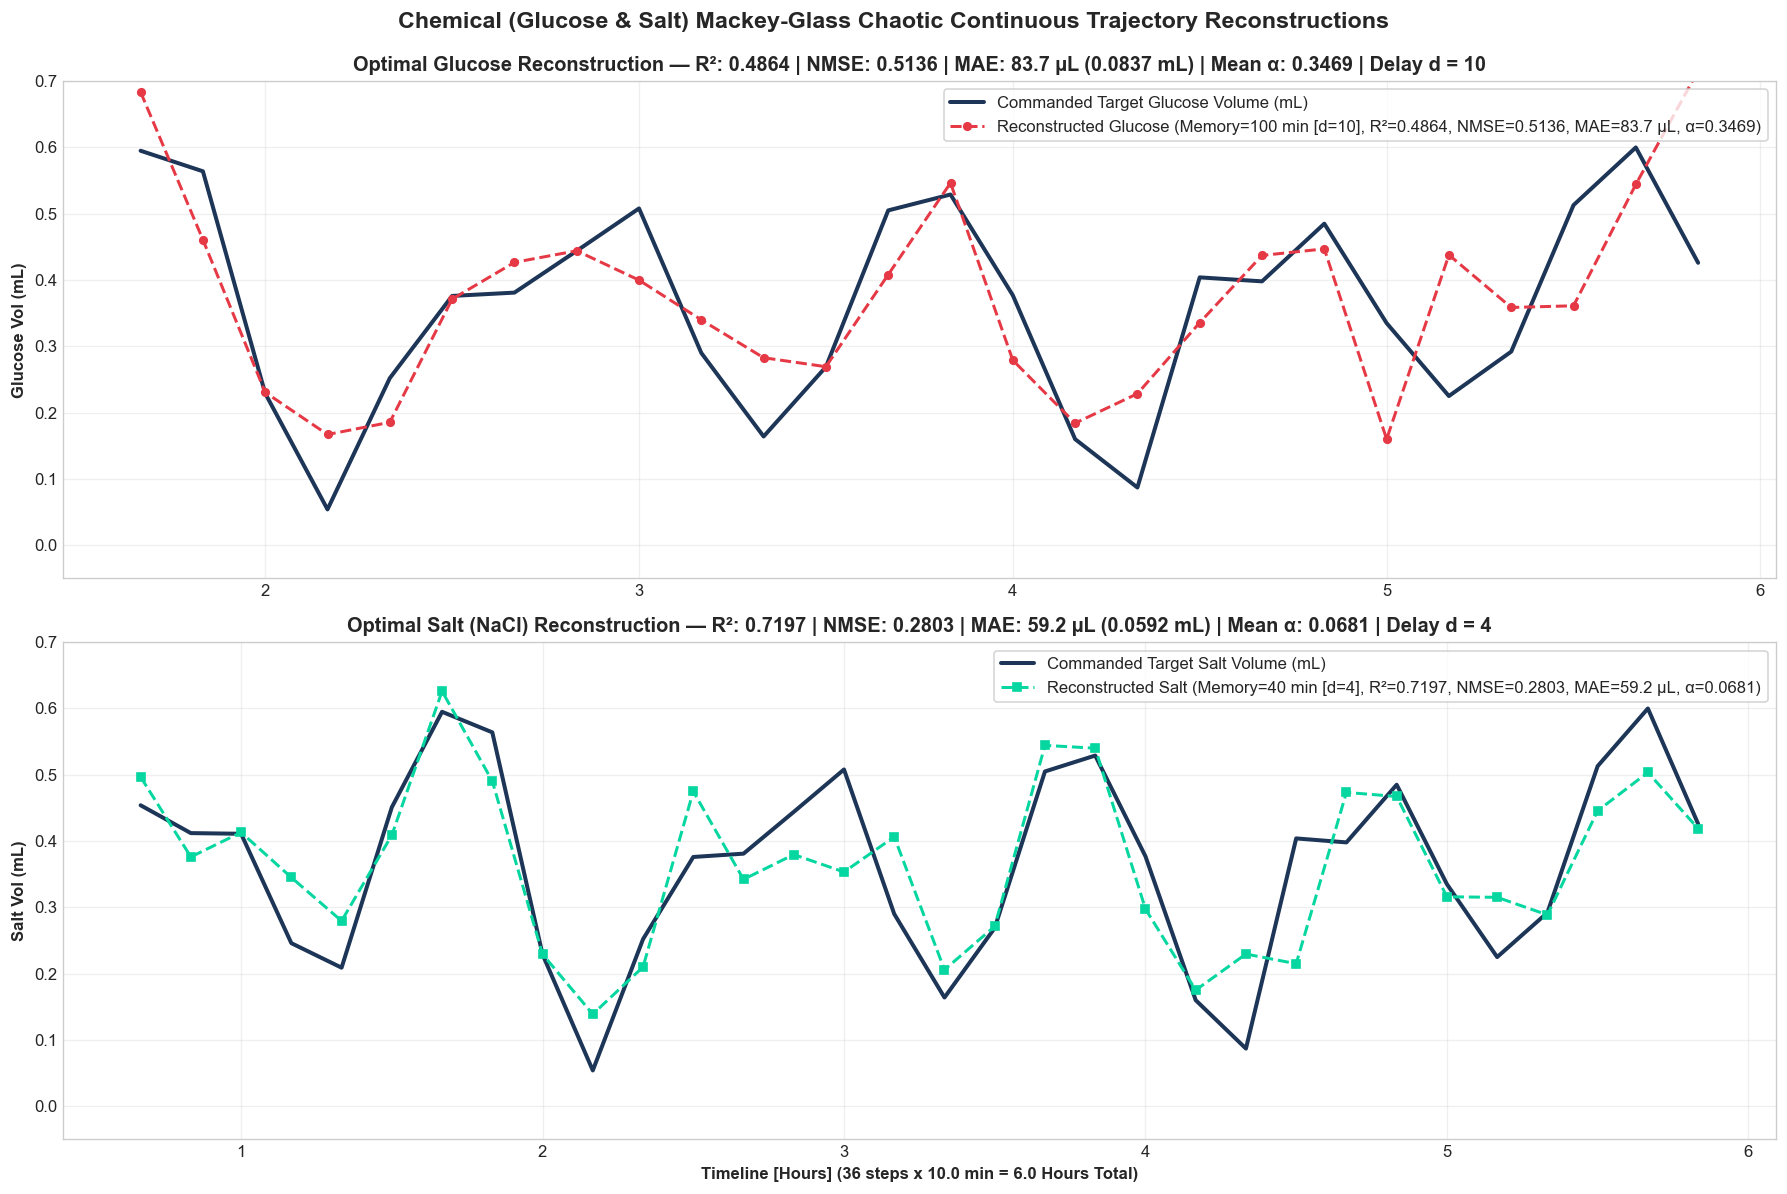

Saved chemical reconstruction plot to: data/mackey glass/chem\results\best_chemical_reconstructions.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# 1. Glucose Reconstruction
opt_d_g, opt_yp_g, opt_yd_g, opt_nmse_g, opt_mae_g, opt_r2_g, opt_a_g = best_gluc
t_plot_g = np.arange(opt_d_g, TOTAL_CYCLES) * (CYCLE_MIN / 60.0)

axes[0].plot(t_plot_g, opt_yd_g, color='#1d3557', lw=2.4, label='Commanded Target Glucose Volume (mL)')
axes[0].plot(t_plot_g, opt_yp_g, color='#e63946', lw=1.8, ls='--', marker='o', ms=4.5, 
             label=f'Reconstructed Glucose (Memory={opt_d_g*CYCLE_MIN:.0f} min [d={opt_d_g}], R²={opt_r2_g:.4f}, NMSE={opt_nmse_g:.4f}, MAE={opt_mae_g*1000:.1f} µL, α={opt_a_g:.4f})')
axes[0].set_title(f'Optimal Glucose Reconstruction — R²: {opt_r2_g:.4f} | NMSE: {opt_nmse_g:.4f} | MAE: {opt_mae_g*1000:.1f} µL ({opt_mae_g:.4f} mL) | Mean α: {opt_a_g:.4f} | Delay d = {opt_d_g}', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Glucose Vol (mL)', fontweight='bold')
axes[0].set_ylim(-0.05, 0.70)
axes[0].legend(loc='upper right', frameon=True, fontsize=10)
axes[0].grid(True, alpha=0.3)

# 2. Salt Reconstruction
opt_d_s, opt_yp_s, opt_yd_s, opt_nmse_s, opt_mae_s, opt_r2_s, opt_a_s = best_salt
t_plot_s = np.arange(opt_d_s, TOTAL_CYCLES) * (CYCLE_MIN / 60.0)

axes[1].plot(t_plot_s, opt_yd_s, color='#1d3557', lw=2.4, label='Commanded Target Salt Volume (mL)')
axes[1].plot(t_plot_s, opt_yp_s, color='#06d6a0', lw=1.8, ls='--', marker='s', ms=4.5, 
             label=f'Reconstructed Salt (Memory={opt_d_s*CYCLE_MIN:.0f} min [d={opt_d_s}], R²={opt_r2_s:.4f}, NMSE={opt_nmse_s:.4f}, MAE={opt_mae_s*1000:.1f} µL, α={opt_a_s:.4f})')
axes[1].set_title(f'Optimal Salt (NaCl) Reconstruction — R²: {opt_r2_s:.4f} | NMSE: {opt_nmse_s:.4f} | MAE: {opt_mae_s*1000:.1f} µL ({opt_mae_s:.4f} mL) | Mean α: {opt_a_s:.4f} | Delay d = {opt_d_s}', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Salt Vol (mL)', fontweight='bold')
axes[1].set_xlabel('Timeline [Hours] (36 steps x 10.0 min = 6.0 Hours Total)', fontweight='bold')
axes[1].set_ylim(-0.05, 0.70)
axes[1].legend(loc='upper right', frameon=True, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Chemical (Glucose & Salt) Mackey-Glass Chaotic Continuous Trajectory Reconstructions', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()

best_recon_path = os.path.join(results_dir, "best_chemical_reconstructions.png")
plt.savefig(best_recon_path, dpi=160)
plt.show()
print(f"Saved chemical reconstruction plot to: {best_recon_path}")
